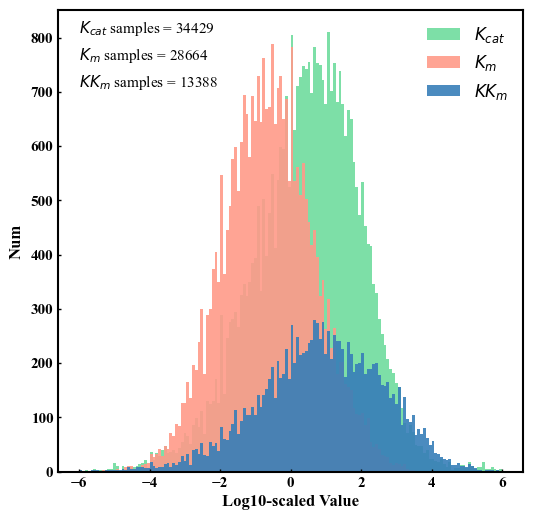

In [1]:
# 加载数据集
import torch
import math
import matplotlib.pyplot as plt
from matplotlib import rc
kcatPair = torch.load("../Data/AnalysisData/KCATTrainPairInfo") + torch.load("../Data/AnalysisData/KCATTestPairInfo")
kmPair = torch.load("../Data/AnalysisData/KMTrainPairInfo") + torch.load("../Data/AnalysisData/KMTestPairInfo")
kkmPair = torch.load("../Data/AnalysisData/KKMTrainPairInfo") + torch.load("../Data/AnalysisData/KKMTestPairInfo")
kcatValue = [ math.log10(item[2]) for item in kcatPair if len(item[3]) == 1]
kmValue = [ math.log10(item[2]) for item in kmPair if len(item[3]) == 1]
kkmValue = [ math.log10(item[2]) for item in kkmPair if len(item[3]) == 1]
rc('font',**{'family':'Times New Roman',})
plt.figure(figsize=(6,6))
plt.rcParams['font.family'] = 'Times New Roman'
plt.hist(kcatValue, 150, (-6,6), color='#7DDFA7', label="$K_{cat}$")
plt.hist(kmValue, 150, (-6,6), color='#FF9A89', label='$K_{m}$', alpha=0.9)
plt.hist(kkmValue, 150, (-6,6), color='#377eb8', label='$KK_{m}$', alpha=0.9)
plt.xlabel('Log10-scaled Value', fontsize=12, weight="bold")
plt.ylabel('Num', fontsize=12, weight="bold")
plt.xticks(fontsize=11, weight="bold")
plt.yticks(fontsize=11, weight="bold")
plt.text(-6, 810, "$K_{cat}$ samples = %d"%len(kcatValue), fontweight ="normal", fontsize=11)
plt.text(-6, 760, "$K_{m}$ samples = %d"%len(kmValue), fontweight ="normal", fontsize=11)
plt.text(-6, 710, "$KK_{m}$ samples = %d"%len(kkmValue), fontweight ="normal", fontsize=11)
plt.tick_params(direction='in')
plt.tick_params(which='major',length=2)
plt.tick_params(which='major',width=1)
plt.legend(frameon=False, prop={"size":12})
ax = plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
plt.savefig("../Figure/Fig2a.png", dpi=600, bbox_inches='tight')

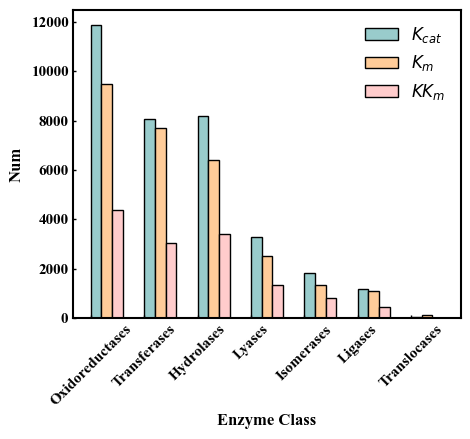

In [2]:
# 加载原始数据集
from collections import defaultdict
import numpy as np
rawData = torch.load("../Data/all_kinetics_data.pt")
# 定义获取每类酶数量的函数
def getEcsNum(pair, data, Type):
    ecIndexDict = defaultdict(list)
    for item in pair:
        if len(item[3]) < 2:
            ecIndexDict[data['kinetics_data'][Type][item[3][0]]['ec'][0]].append(math.log10(item[2]))
    return dict(ecIndexDict)
kcatEcsNum = getEcsNum(kcatPair, rawData, 'kcat')
kmEcsNum = getEcsNum(kmPair, rawData, 'km')
kkmEcsNum = getEcsNum(kkmPair, rawData, 'kkm')
rc('font',**{'family':'Times New Roman',})
plt.figure(figsize=(5,4))
plt.rcParams['font.family'] = 'Times New Roman'
width = 0.2
x = np.arange(7)

plt.bar(x-width, [ len(kcatEcsNum[f'{i}']) for i in range(1,8)], width=width,edgecolor="black" , color="#99CCCC", label="$K_{cat}$")
plt.bar(x, [ len(kmEcsNum[f'{i}']) for i in range(1,8)], width=width,edgecolor="black", color="#FFCC99", label="$K_{m}$")
plt.bar(x+width, [ len(kkmEcsNum[f'{i}']) for i in range(1,8)], width=width,edgecolor="black", color="#FFCCCC", label="$KK_{m}$")

plt.xlabel('Enzyme Class', fontsize=12, weight="bold")
plt.ylabel('Num', fontsize=12, weight="bold")

plt.xticks(x-3*width/2, ["Oxidoreductases", "Transferases", "Hydrolases", "Lyases", "Isomerases", "Ligases", "Translocases"],rotation=45,fontsize=11, weight="bold")
plt.yticks(fontsize=11, weight="bold")

plt.tick_params(direction='in')
plt.tick_params(which='major',length=2)
plt.tick_params(which='major',width=1)
plt.legend(frameon=False, prop={"size":12})

ax = plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

plt.savefig("../Figure/Fig2b.png", dpi=600, bbox_inches='tight')

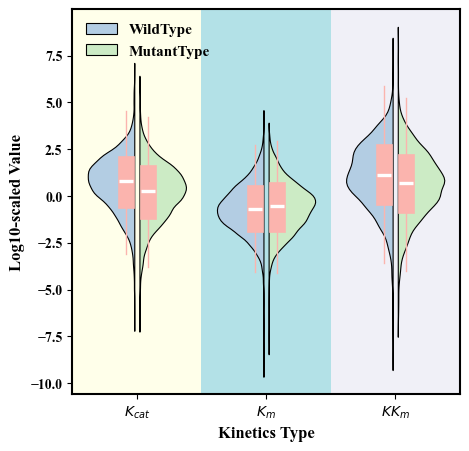

In [5]:
import seaborn as sns
import matplotlib.patches as patches
import pandas as pd
kcat_df = pd.DataFrame(rawData['kinetics_data']['kcat'])
km_df = pd.DataFrame(rawData['kinetics_data']['km'])
kkm_df = pd.DataFrame(rawData['kinetics_data']['kkm'])
kcat_df['kinetics_type'] = 'kcat'
km_df['kinetics_type'] = 'km'
kkm_df['kinetics_type'] = 'kkm'
data = pd.concat([kcat_df, km_df, kkm_df], axis=0)
data['value'] = data['value'].astype(float)
data = data[data['value'] > 0]
data['value'] = np.log10(data['value'])
plt.figure(figsize=(5,5))
ax = sns.violinplot(data, x='kinetics_type', 
               y='value', 
               hue='type', 
               split=True, 
#                log_scale=10, 
               inner="box", 
               dodge=True, 
               gap=0.1, 
               inner_kws=dict(box_width=12, whis_width=1, color='#fbb4ae'),
               density_norm='width',
               common_norm=True,
               palette={'wild':'#b3cde3', 'mutant':'#ccebc5'},
#                legend='full'
               linewidth=0.8,
               linecolor='#000',
               saturation=1
              )
rect1 = patches.Rectangle((-0.5, -11.0), 1, 21, facecolor='#ffffcc', zorder=0, alpha=0.4)
rect2 = patches.Rectangle((0.5, -11.0), 1, 21, facecolor='#41b6c4', zorder=0, alpha=0.4)
rect3 = patches.Rectangle((1.5, -11.0), 1, 21, facecolor='#dadaeb', zorder=0, alpha=0.4)
ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)
# plt.legend(frameon=True, prop={"size":11, 'weight':'bold', 'family':'Times New Roman'})
ax.set_ylabel("Log10-scaled Value", fontdict={'family':'Times New Roman', 'weight':'bold', 'size':12})
ax.set_xlabel("Kinetics Type", fontdict={'family':'Times New Roman', 'weight':'bold', 'size':12})
plt.yticks(**{'family':'Times New Roman', 'weight':'bold', 'size':10})
plt.xticks(ticks=[0,1,2],labels=['$K_{cat}$', '$K_{m}$', '$KK_{m}$'],**{'family':'Times New Roman', 'weight':'bold', 'size':10})
plt.legend(handles=[ax.collections[0], ax.collections[1]], frameon=False,loc=2,labels=['WildType', 'MutantType'], prop={"size":11, 'family':'Times New Roman', 'weight':'bold'})
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
plt.savefig(f"../Figure/Fig2c.png", dpi=600, bbox_inches='tight')